Saving cavalo.jpg to cavalo (1).jpg


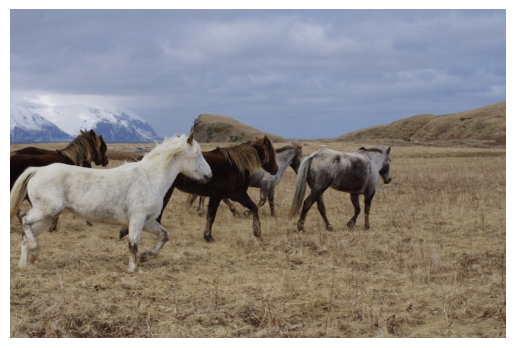

In [1]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = Image.open(image_path).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

## Implementação 1 - Detecção de objetos com YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/cavalo (1).jpg: 448x640 5 horses, 470.6ms
Speed: 16.0ms preprocess, 470.6ms inference, 31.1ms postprocess per image at shape (1, 3, 448, 640)


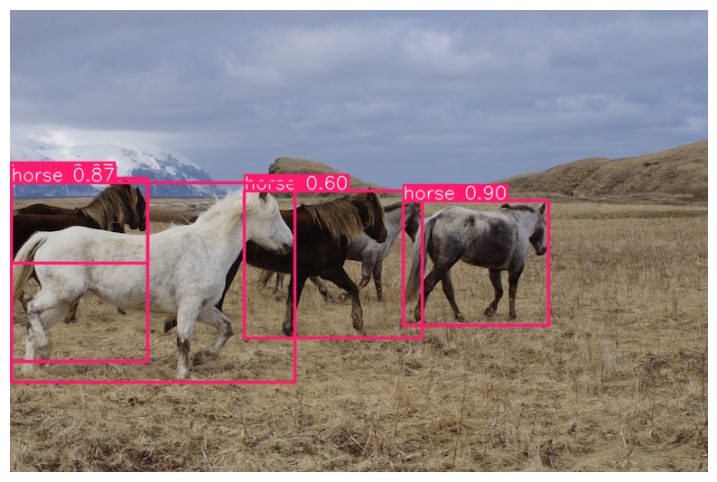

In [2]:
!pip -q install ultralytics

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

modelo = YOLO("yolov8n.pt")

resultado = modelo(image_path)[0]

imagem = cv2.cvtColor(resultado.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(imagem)
plt.axis("off")
plt.show()

## Implementação 2 - Descrição automática da imagem

In [3]:
!pip -q install transformers accelerate sentencepiece

import torch

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration
)

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

modelo = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

inputs = processor(img, return_tensors="pt").to(device)

saida = modelo.generate(**inputs)

descricao = processor.decode(
    saida[0],
    skip_special_tokens=True
)

print(descricao)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


a group of horses grazing in a field


## Conclusão

Nesta atividade foi utilizada uma imagem para aplicar duas técnicas apresentadas durante a aula de Visão Computacional com Deep Learning. Inicialmente, foi realizada a detecção de objetos utilizando o modelo YOLOv8, permitindo identificar automaticamente os elementos presentes na imagem. Em seguida, foi empregada uma abordagem multimodal com o modelo BLIP para gerar uma descrição textual do conteúdo da imagem.

Os resultados obtidos demonstram como diferentes técnicas de visão computacional podem ser aplicadas de forma complementar, permitindo tanto a identificação de objetos quanto a interpretação do contexto visual. Essas implementações evidenciam aplicações práticas de Deep Learning em problemas reais de análise e compreensão de imagens.
